In [29]:

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from bootcampviztools import plot_combined_graphs, pinta_distribucion_categoricas, plot_categorical_relationship_fin,\
      plot_grouped_boxplots,plot_grouped_histograms, grafico_dispersion_con_correlacion, plot_categorical_numerical_relationship, bubble_plot
from scipy.stats import pearsonr, chi2_contingency, mannwhitneyu,f_oneway

Cargo los datos inmobiliarios

In [30]:
df_inm = pd.read_csv("EDA_Inmobiliario_Madrid", sep=",")

In [31]:
df_inm.head(5)

,titulo,precio,habitaciones,m2,altura,zona
0,"Piso en Calle de las Almortas, Valdeacederas, ...",1.590€/mes,2,74,Planta 2ª exterior sin ascensor,"Valdeacederas, Madrid"
1,"Piso en Calle Esquilache, 14, Vallehermoso, Ma...",1.500€/mes,2,100,Bajo exterior con ascensor,"Vallehermoso, Madrid"
2,"Piso en Calle de Olite, 48, Bellas Vistas, Madrid",1.700€/mes,2,68,Planta 4ª exterior con ascensor,"Bellas Vistas, Madrid"
3,"Piso en Paseo de La Habana, El Viso, Madrid",2.950€/mes,2,134,Planta 2ª exterior con ascensor,"El Viso, Madrid"
4,Piso en Calle de Raimundo Fernández Villaverde...,1.450€/mes,2,43,Planta 1ª interior con ascensor,"Cuatro Caminos, Madrid"


In [32]:
# Correccion de los datos

df_inm['piso'] = df_inm['altura'].str.extract(r'(\d+)')   #quiero extraer uno o más dígitos dentro de a columna altura
df_inm['piso'] = df_inm['piso'].fillna(0)  # ejemplo: bajos = 0
df_inm['precio'] = pd.to_numeric(df_inm['precio'].str.replace('€/mes', '', regex=False).str.replace('.', '', regex=False).str.strip()) 
df_inm.head(5)

,titulo,precio,habitaciones,m2,altura,zona,piso
0,"Piso en Calle de las Almortas, Valdeacederas, ...",1590,2,74,Planta 2ª exterior sin ascensor,"Valdeacederas, Madrid",2
1,"Piso en Calle Esquilache, 14, Vallehermoso, Ma...",1500,2,100,Bajo exterior con ascensor,"Vallehermoso, Madrid",0
2,"Piso en Calle de Olite, 48, Bellas Vistas, Madrid",1700,2,68,Planta 4ª exterior con ascensor,"Bellas Vistas, Madrid",4
3,"Piso en Paseo de La Habana, El Viso, Madrid",2950,2,134,Planta 2ª exterior con ascensor,"El Viso, Madrid",2
4,Piso en Calle de Raimundo Fernández Villaverde...,1450,2,43,Planta 1ª interior con ascensor,"Cuatro Caminos, Madrid",1


In [33]:
# Em Chile el nivel bajo se considera un primer piso, o primera planta
df_inm['piso'] = pd.to_numeric(df_inm['piso']) 

df_inm['piso'] = df_inm['piso'] + 1

In [34]:
df_inm['precioeu_m2'] = df_inm['precio']/df_inm['m2']


In [35]:
df_inm = df_inm[['titulo','piso','m2','precio', 'habitaciones','precioeu_m2']]

df_inm.head(3)

,titulo,piso,m2,precio,habitaciones,precioeu_m2
0,"Piso en Calle de las Almortas, Valdeacederas, ...",3,74,1590,2,21.486486
1,"Piso en Calle Esquilache, 14, Vallehermoso, Ma...",1,100,1500,2,15.000000
2,"Piso en Calle de Olite, 48, Bellas Vistas, Madrid",5,68,1700,2,25.000000


In [36]:
df_inm.info()

<class 'pandas.DataFrame'>
RangeIndex: 630 entries, 0 to 629
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   titulo        630 non-null    str    
 1   piso          630 non-null    int64  
 2   m2            630 non-null    int64  
 3   precio        630 non-null    int64  
 4   habitaciones  630 non-null    int64  
 5   precioeu_m2   630 non-null    float64
dtypes: float64(1), int64(4), str(1)
memory usage: 29.7 KB


In [37]:
df_inm.describe()

,piso,m2,precio,habitaciones,precioeu_m2
count,630.000000,630.000000,630.000000,630.000000,630.000000
mean,4.866667,104.366667,2415.000000,2.466667,23.491368
std,3.276063,42.144016,1007.632518,0.718593,5.266812
min,1.000000,43.000000,1100.000000,2.000000,15.000000
25%,3.000000,75.000000,1590.000000,2.000000,19.750000
50%,4.000000,95.000000,2175.000000,2.000000,22.007463
75%,6.000000,134.000000,3000.000000,3.000000,26.736111
max,18.000000,235.000000,4800.000000,5.000000,34.313725


(2,)


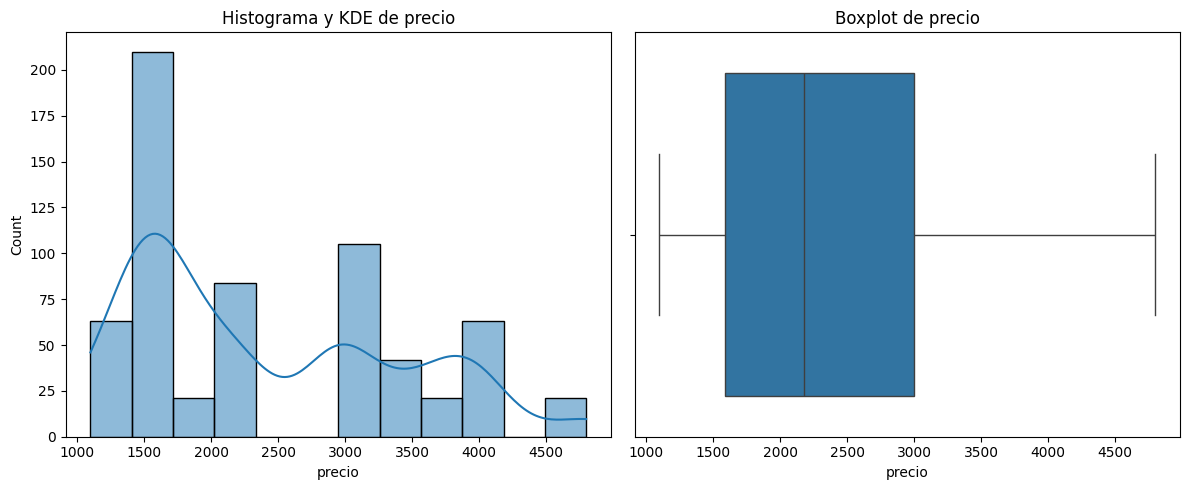

In [38]:
# El 50% es la mediana, el 50% de los datos están por debajo de ese numero

plot_combined_graphs(df_inm,["precio"])

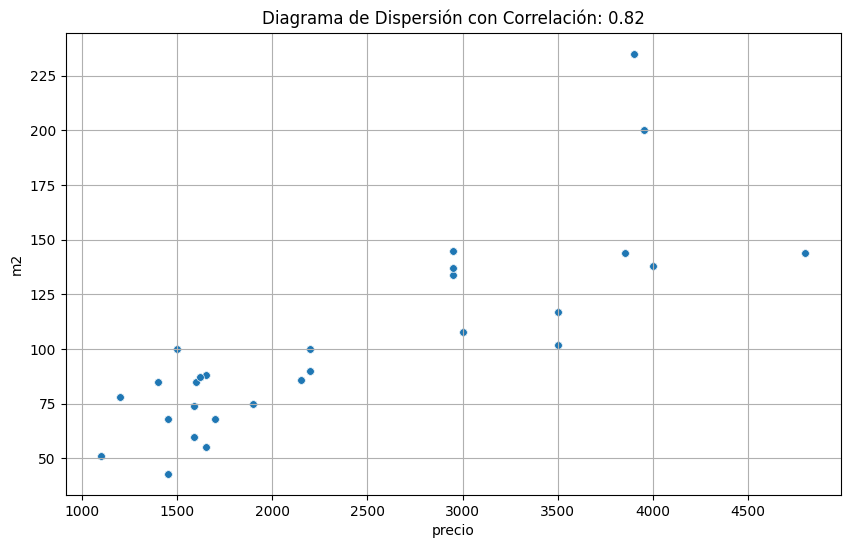

In [39]:
# Análisis bivariante
grafico_dispersion_con_correlacion(df_inm, "precio","m2", mostrar_correlacion= True, tamano_puntos= 30)

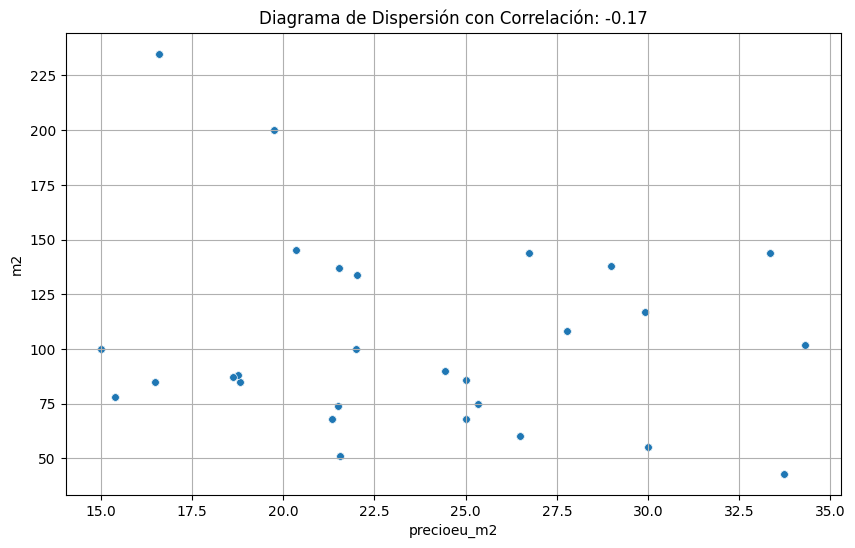

In [40]:
# Análisis bivariante

grafico_dispersion_con_correlacion(df_inm, "precioeu_m2","m2", mostrar_correlacion= True, tamano_puntos= 30)

In [41]:
# Análisis por grupo

rangos = [0, 40, 60, 80,100,120, float('inf')]
etiquetas = ['<40', '40-60', '60-80', '80-100','100-120','>120']

df_inm['grupo_m2'] = pd.cut(df_inm['m2'], bins=rangos, labels=etiquetas)

df_inm.groupby('grupo_m2')['precioeu_m2'].describe()

,count,mean,std,min,25%,50%,75%,max
grupo_m2,,,,,,,,
40-60,84.0,27.947389,4.508280,21.568627,25.267157,28.250000,30.930233,33.720930
60-80,105.0,21.705593,3.599425,15.384615,21.323529,21.486486,25.000000,25.333333
80-100,189.0,20.123250,3.256227,15.000000,18.620690,18.823529,22.000000,25.000000
100-120,63.0,30.668678,2.742911,27.777778,27.777778,29.914530,34.313725,34.313725
>120,189.0,23.478691,4.925849,16.595745,20.344828,22.014925,26.736111,33.333333


In [43]:
filtro = (df_inm.habitaciones == 2)&(df_inm.m2 >= 60)&(df_inm.m2 <= 80) 
df_inmf = df_inm[filtro]
df_inmf.head(30)

,titulo,piso,m2,precio,habitaciones,precioeu_m2,grupo_m2
0,"Piso en Calle de las Almortas, Valdeacederas, ...",3,74,1590,2,21.486486,60-80
2,"Piso en Calle de Olite, 48, Bellas Vistas, Madrid",5,68,1700,2,25.000000,60-80
15,"Piso en Ps Direccion, Valdeacederas, Madrid",2,78,1200,2,15.384615,60-80
19,"Piso en Calle de Ríos Rosas, Nuevos Ministerio...",6,60,1590,2,26.500000,40-60
24,"Piso en Calle de Cea Bermúdez, 13, Arapiles, M...",5,75,1900,2,25.333333,60-80
30,"Piso en Calle de las Almortas, Valdeacederas, ...",3,74,1590,2,21.486486,60-80
32,"Piso en Calle de Olite, 48, Bellas Vistas, Madrid",5,68,1700,2,25.000000,60-80
45,"Piso en Ps Direccion, Valdeacederas, Madrid",2,78,1200,2,15.384615,60-80
49,"Piso en Calle de Ríos Rosas, Nuevos Ministerio...",6,60,1590,2,26.500000,40-60
54,"Piso en Calle de Cea Bermúdez, 13, Arapiles, M...",5,75,1900,2,25.333333,60-80


In [ ]:
# FILTRO PARA BÚSQUEDA FAMILIA
filtro = (df_inm.habitaciones >= 1)&(df_inm.m2 >= 60)&(df_inm.m2 <= 80) 
df_inmfil = df_inm[filtro]


rangos = [0, 40, 60, 80,100,120, float('inf')]
etiquetas = ['<40', '40-60', '60-80', '80-100','100-120','>120']

df_inm['grupo_m2'] = pd.cut(df_inm['m2'], bins=rangos, labels=etiquetas)

df_inm.groupby('grupo_m2')['precioeu_m2'].describe()[["50%"]]

,50%
grupo_m2,
40-60,26.500000
60-80,21.486486


In [18]:
# Para el grupo de 40–60 m², media ≈ 11.59 euro/m2 y la desviación es std ≈ 3.67

'''Esto significa que: Los precios suelen variar alrededor del promedio en ±3.67 (aprox.)
Es decir, muchos valores estarán entre: ~8 y ~15 (aproximadamente)

✅ En tu caso (precios por m²)
Desviación estándar alta
👉 Los precios dentro de ese grupo son muy variados
👉 Hay pisos baratos y caros aunque tengan tamaño similar
Desviación estándar baja
👉 Los precios son más consistentes
👉 El tamaño explica mejor el precio
'''

# Departamentos de menos de 60m2
filtro2 = (df_inm.m2 < 40)
df_inm40 = df_inm[filtro2]

df_inm40.head(2)

,titulo,piso,m2,precio,habitaciones,precioeu_m2,grupo_m2


In [ ]:
filtro = (df_inm.dormitorios > 1) #filtro por 2 dormitorios
df_inm2 = df_inm[filtro]
df_inm2.head(10)


NameError: name 'df_inm2' is not defined